# CPPN playground: select an image, mutate its network

**First question:** can we comfortably select and evolve CPPN images inside a notebook?

A CPPN is a function evaluated at each pixel: `(x, y, radius) → (hue, saturation, brightness) → RGB`. The same network produces every pixel. NEAT supplies an encoding of the graph and operators that change its weights and structure.

This notebook uses human choice to help us understand those operations. It is a learning prototype, not an automated UFR experiment. We use NEAT-Python's genomes and mutations, without its full population/speciation/crossover algorithm.

Run cells in order with this project's Python kernel. The buttons need a live kernel. Launch from the project root with `uv run jupyter lab notebooks/01_cppn_selection.ipynb`.

In [1]:
from pathlib import Path
import random
from copy import deepcopy

import neat
from IPython.display import display
from PIL import Image
import ipywidgets as widgets

from automated_picbreeder.cppn import (
    load_config, new_genome, coordinates, render, png_bytes, genome_from_dict,
)
from automated_picbreeder.notebook import CPPNPlayground

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

## 1. Render one CPPN

The x and y coordinates range from −1 to 1. Radius is distance from the centre (0 to √2); y increases down the image. Three fixed sigmoid outputs produce hue, saturation and brightness in [0, 1]. HSB is also called HSV; brightness is value, not HSL lightness. The renderer wraps hue at 1 and converts HSB to RGB. Hidden nodes use a mixture of activation functions.

There is no learned pixel array: an image is the result of repeatedly evaluating a small network. No training or optimisation happens in this cell.

Brightness at the centre: 0.2839653418705932
Pixel inputs at the top-left: [-1.         -1.          1.41421356]


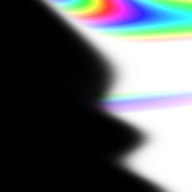

In [2]:
config = load_config()
genome = new_genome(key=0, config=config, rng=random.Random(7))
net = neat.nn.FeedForwardNetwork.create(genome, config)

print("Brightness at the centre:", net.activate([0.0, 0.0, 0.0])[0])
print("Pixel inputs at the top-left:", coordinates(96)[0, 0])
display(Image.fromarray(render(genome, config, size=192)))

## 2. Select and evolve

Click **Select** beneath one of the nine images, then **Mutate selected**. The selected parent remains unchanged in position 1; the other eight images are independent mutated copies. Each card shows its genome ID, hidden-node count and enabled-connection count.

- Begin with small mutations and try preserving a pattern for several rounds.
- Disable **Allow structure / activation changes** to isolate weight and bias changes. Compare σ = 0.05 with σ = 0.5. The slider controls the perturbation standard deviation, not the resulting image difference.
- Enable structure changes to allow nodes/connections to be added or removed, connections toggled and hidden activations changed. These changes are probabilistic.
- **Back** restores an earlier grid; evolving again creates a fresh branch. **New random images** creates a fresh set of roots. Both retain previous candidates in memory.
- **Save session** exports the genomes, ancestry, displayed alternatives, choices, config, every generated image and shared JSON/CSV metrics. Save before restarting the kernel or rerunning the cell below.

The interface updates through `ipywidgets` callbacks; it does not wait in a blocking input loop. Identical and flat images are kept. With σ = 0 and structure changes disabled, offspring will be identical to the parent.

In [3]:
playground = CPPNPlayground(seed=9, size=96, save_dir=ROOT / "runs")
playground.display()

## 3. Inspect the current choice

After selecting an image above, rerun this cell to inspect its graph encoding. If you have not selected an image, it uses the first candidate. Negative node IDs are inputs: −1 = x, −2 = y, −3 = radius. Nodes 0, 1 and 2 are hue, saturation and brightness outputs, respectively. IDs above 2 are hidden nodes.

The interface's hidden-node count includes nodes that may not contribute to the output. An enabled connection is not by itself evidence that an image property depends on it.

In [ ]:
chosen_id = playground.selected_id if playground.selected_id is not None else playground.candidates[0]
chosen = playground.genomes[chosen_id]
print(chosen)
display(Image.fromarray(render(chosen, playground.config, size=192)))

## 4. Change one weight

Choose an enabled connection, copy the genome and vary only that weight. Each image uses the same HSB channel scales; there is no per-image normalization. Rerun the previous cell to inspect a new selection, then rerun this cell.

A useful observation is whether the same feature changes across a range of weights while other features persist. This is exploratory: visual variation alone does not establish selective semantic control or shared computation. We will need explicit attributes and intervention criteria later.

In [ ]:
enabled = [key for key, connection in chosen.connections.items() if connection.enabled]
if not enabled:
    print("This network has no enabled connections. Select another image.")
else:
    edge = enabled[0]  # Replace with another tuple from the printed genome, e.g. (-1, 0).
    original_weight = chosen.connections[edge].weight
    previews = []
    for delta in (-0.5, -0.25, 0.0, 0.25, 0.5):
        variant = deepcopy(chosen)
        variant.connections[edge].weight = original_weight + delta
        previews.append(widgets.VBox([
            widgets.Image(value=png_bytes(render(variant, playground.config, 96)),
                          format="png", width=120, height=120),
            widgets.Label(value=f"w = {original_weight + delta:.2f}"),
        ]))
    print(f"Connection {edge}: original weight {original_weight:.3f}")
    display(widgets.HBox(previews, layout=widgets.Layout(flex_flow="row wrap")))

## 5. Save and re-render

The button saves without leaving the notebook. The equivalent Python call is shown below. An exported session retains every generated genome, including alternatives you did not select. It also saves `metrics.json`, `metrics.csv`, selected candidate grids and interaction timing, using the same metric definitions as automated runs. No classifier runs when you save. These exports support inspection and rendering; they do not restore a live evolution session.

Uncomment this cell when you want to save. It will use the current selected image.

In [ ]:
# import json
# saved = playground.save()
# data = json.loads((saved / "session.json").read_text())
# restored_config = load_config(saved / "cppn.cfg")
# chosen_record = next(g for g in data["genomes"] if g["key"] == data["selected"])
# restored = genome_from_dict(chosen_record)
# display(Image.fromarray(render(restored, restored_config, size=data["size"])))

## 6. Inspect the saved metrics

After pressing **Save session**, `playground.last_saved_dir` points to that export. Open `index.html` in that folder in your browser for the interactive image and metric viewer. It works offline; keep the image folders beside the report. The report keeps every selection click in chronological order. Re-selecting on the same grid does not count as another candidate presentation; Back and reset visits do. `round` is the notebook round, while `generation` is the chronological selection index and can include reselections.

`final_ancestry` follows the actual saved genome parents. It can differ from the chronological selections after Back or resets. `display_history` retains all grid visits, including ones without a selection. Use candidate presentations, generated genomes and matching mutation settings when comparing exploration budgets. Human interaction time includes thinking and idle time, so it is separate from automated runtime.

Uncomment this cell to inspect the most recent export.


In [ ]:
# import json
# saved = playground.last_saved_dir
# if saved is None:
#     raise ValueError("Save the session first.")
# metrics = json.loads((saved / "metrics.json").read_text())
# print(metrics["summary"])
# print("Final ancestry:", [node["genome_id"] for node in metrics["final_ancestry"]])
# print("Metric files:", saved / "metrics.json", saved / "metrics.csv")
# print("Interactive viewer:", saved / "index.html")


### Optional: evaluate saved images with a frozen ImageNet classifier

This is a separate post-run analysis for human **or** automated sessions. Use the same explicit model, checkpoint and preprocessing for comparisons. It requires the `imagenet` extra and may download the checkpoint. Each saved genome is classified once, including rejects and discarded branches. Results and cost are kept separate from selection-time measurements under `posthoc_*` fields; the original session and human choices are unchanged. Confidence is not a validated measure of interestingness.

Uncomment only when you want to run this analysis. Existing batch aggregates are not rewritten by this per-session operation. See [metric definitions](../docs/batch-experiments.md).


In [ ]:
# from automated_picbreeder.imagenet import ImageNetEvaluator
# from automated_picbreeder.posthoc_evaluation import evaluate_session_imagenet
# from automated_picbreeder.experiment_metrics import save_run_metrics
# saved = playground.last_saved_dir
# if saved is None:
#     raise ValueError("Save the session first.")
# evaluator = ImageNetEvaluator(model_name="resnet18", weights="IMAGENET1K_V1",
#                               device="cpu", cache_dir=ROOT / ".cache" / "imagenet")
# evaluate_session_imagenet(saved, evaluator=evaluator)
# metrics = save_run_metrics(saved)
# print(metrics["summary"]["posthoc_classifier_images"])


## Where this leads

1. **CPPN understanding:** image selection, weight/topology mutation, then graph and activation-map inspection.
2. **Automated evolution:** compare random, greedy ImageNet and epsilon-greedy ImageNet selection strategies in the same nine-image loop. Keep one parent and mutate eight offspring. Record every candidate and decision; distinguish candidate presentations from classifier evaluations. Notebook 02 demonstrates the Python interface; the [README](../README.md#automated-selection-experiments) documents the CLI.
3. **Pilot assessment:** measure cost and define semantic attributes, intervention ranges, tolerated unintended changes, image preservation and shared-computation tests. Separate discovery from held-out intervention evaluation.
4. **Frozen experiment:** fix selection strategies, epsilon values, seeds, decision budgets, checkpoint intervals and sampling rules; report evaluation costs separately. Assess both selective control and shared computation, including duplicate images, unrecognisable images, failures and uncertainty. Record meaningful variation and classifier-label changes as secondary outcomes.
5. **Human-choice follow-up:** a separate study on the same candidate sets, with a specified classifier choice rule and complete decision context.

The claim is about the sufficiency of the complete automated system. Classifier confidence is not validated naturalness, and selective control alone does not prove shared computation. See [the supplied brief](../docs/experiment-brief.md).

Implementation references: [NEAT-Python configuration](https://neat-python.readthedocs.io/en/latest/config_file.html) and [ipywidgets callbacks](https://ipywidgets.readthedocs.io/en/latest/reference/ipywidgets.html). The prototype uses NEAT-Python 2.0.0; its installed source defines the precise behaviour.